# Electricity Consumption in Spain

## Data Cleaning and Analysis

## Setup

We use Polars because Table A is large. Lazy Parquet scanning allows us to work with the data without loading all 16 million records into memory at once.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path
import polars as pl

In [3]:
PROJECT_ROOT = Path.cwd().parent

A_PATH = PROJECT_ROOT / "data" / "A_cleaned.parquet"

if not A_PATH.exists():
    raise FileNotFoundError(
        f"Could not find Table A at: {A_PATH}\n"
        "Make sure the notebook is inside the EDA folder."
    )

A = pl.scan_parquet(str(A_PATH))
A.head().collect()

CUSTOMER_ID,DATE,ACTIVE_H1,REACTIVE_H1,ACTIVE_H2,REACTIVE_H2,ACTIVE_H3,REACTIVE_H3,ACTIVE_H4,REACTIVE_H4,ACTIVE_H5,REACTIVE_H5,ACTIVE_H6,REACTIVE_H6,ACTIVE_H7,REACTIVE_H7,ACTIVE_H8,REACTIVE_H8,ACTIVE_H9,REACTIVE_H9,ACTIVE_H10,REACTIVE_H10,ACTIVE_H11,REACTIVE_H11,ACTIVE_H12,REACTIVE_H12,ACTIVE_H13,REACTIVE_H13,ACTIVE_H14,REACTIVE_H14,ACTIVE_H15,REACTIVE_H15,ACTIVE_H16,REACTIVE_H16,ACTIVE_H17,REACTIVE_H17,ACTIVE_H18,REACTIVE_H18,ACTIVE_H19,REACTIVE_H19,ACTIVE_H20,REACTIVE_H20,ACTIVE_H21,REACTIVE_H21,ACTIVE_H22,REACTIVE_H22,ACTIVE_H23,REACTIVE_H23,ACTIVE_H24,REACTIVE_H24,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
i64,date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,cat,cat,cat
67072,2015-07-23,194,1,148,0,108,1,109,2,107,0,108,0,115,6,232,64,216,34,357,8,2943,603,1624,347,2142,377,2570,491,1994,391,8192906,188,104,1,101,0,141,0,344,46,3303,853,776,179,2866,649,2041,453,0,0,"""CASTELLON DE LA PLANA""","""Q12013""",null,"""T1""","""P17""","""M2"""
11933,2015-01-11,139194,0,129014,0,119181,0,112334,0,110510,0,115472,0,116996,0,113849,0,82597,0,69862,0,73648,0,67530,0,69331,0,69631,0,68792,0,61337,0,58759,0,61631,0,112805,0,146865,0,150367,0,154261,0,135836,0,141930,0,0,0,"""MADRID""",null,null,"""T2""","""P72""","""M2"""
10745,2015-02-24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,51417,0,137113,0,137113,0,154252,0,137113,0,154252,0,137113,0,137113,0,137113,0,137113,0,154252,0,0,0,"""MADRID""","""Q32013""",null,"""T2""","""P13""","""M2"""
10618,2015-02-28,45143,0,36499,0,31298,0,28421,0,27124,0,27113,0,28427,0,31998,0,39622,0,50823,0,60310,0,64333,0,65918,0,67494,0,64888,0,59344,0,55623,0,54511,0,57982,0,63571,0,67528,0,68476,0,63079,0,54286,0,0,0,"""MADRID""","""Q22009""",null,"""T2""","""P30""","""M2"""
10618,2015-03-01,42833,0,35405,0,31139,0,28567,0,27026,0,26621,0,27120,0,29711,0,34712,0,43900,0,51524,0,56005,0,57116,0,58000,0,57917,0,51760,0,49078,0,48231,0,50936,0,59501,0,67801,0,68563,0,59820,0,49401,0,0,0,"""MADRID""","""Q22009""",null,"""T2""","""P30""","""M2"""


## Active and Reactive electricity consumption columns

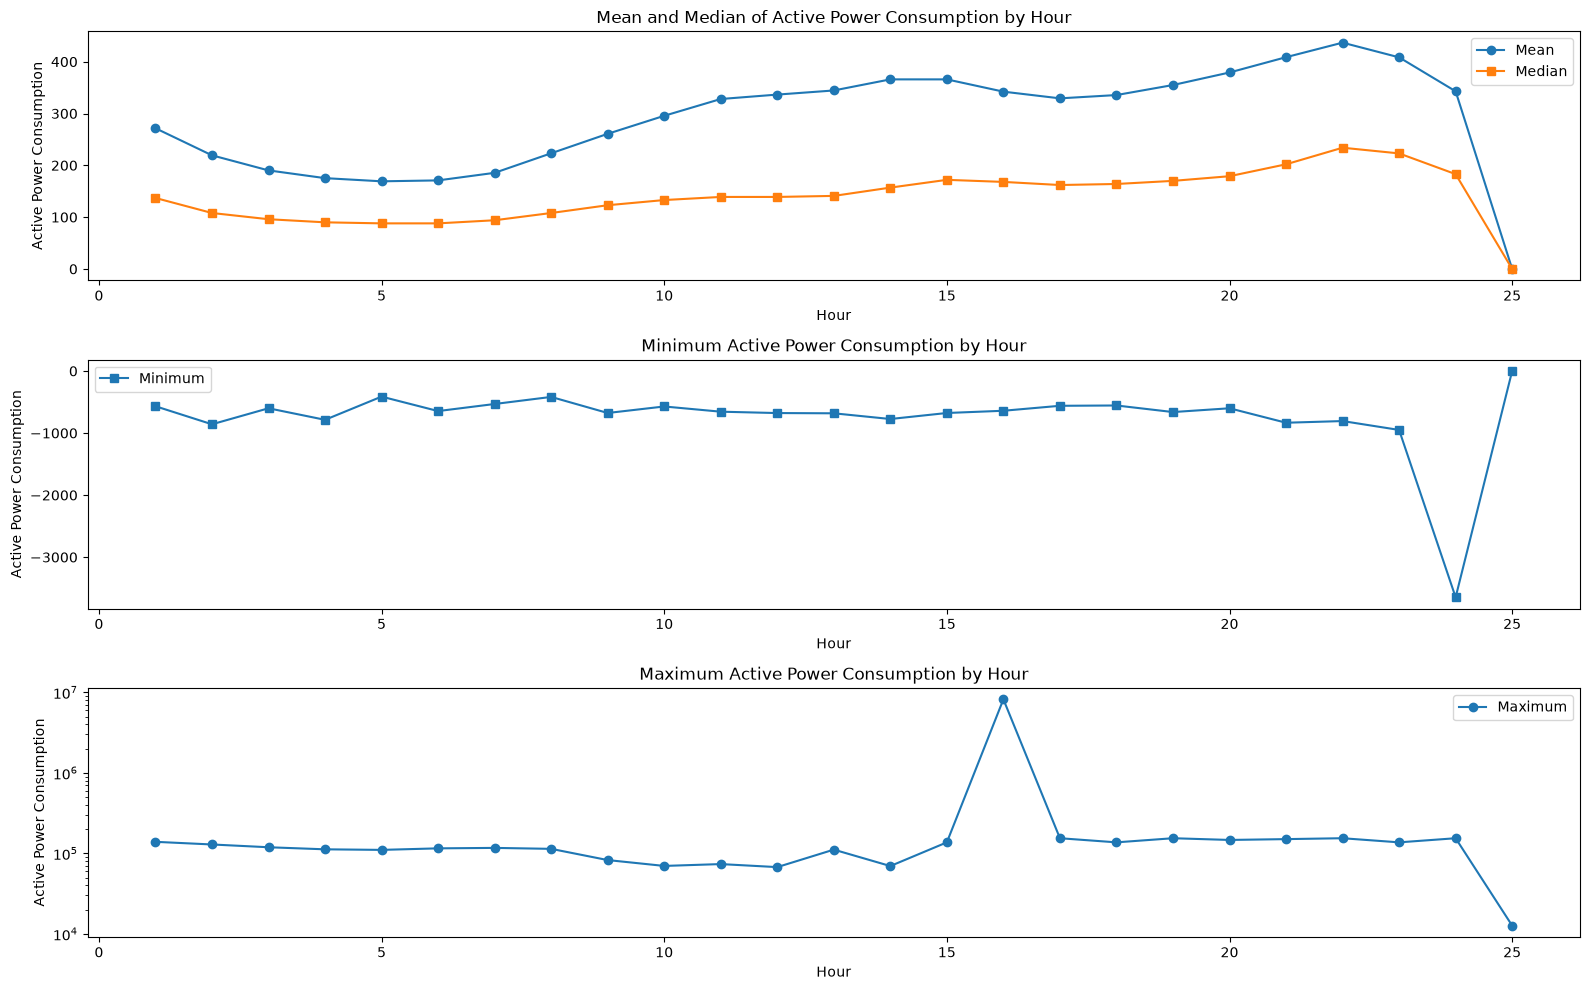

In [13]:
active_cols = [f"ACTIVE_H{i}" for i in range(1, 26)]
active_stats = []
for c in active_cols:
    row = (
        A.select([
            pl.col(c).min().alias("minimum"),
            pl.col(c).max().alias("maximum"),
            pl.col(c).mean().alias("mean"),
            pl.col(c).median().alias("median"),
        ])
        .collect()
        .row(0)
    )
    active_stats.append({
        "column": c,
        "minimum": row[0],
        "maximum": row[1],
        "mean": row[2],
        "median": row[3],
    })
active_stats_df = pl.DataFrame(active_stats)

time_position = list(range(1, 26))

plt.figure(figsize=(16, 10))

plt.subplot(3,1,1)
plt.plot(time_position, active_stats_df["mean"], marker='o', label='Mean')
plt.plot(time_position, active_stats_df["median"], marker='s', label='Median')
plt.title("Mean and Median of Active Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Active Power Consumption")
plt.legend()

plt.subplot(3,1,2)
plt.plot(time_position, active_stats_df["minimum"], marker='s', label='Minimum')
plt.title("Minimum Active Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Active Power Consumption")
plt.legend()

plt.subplot(3,1,3)
plt.plot(time_position, active_stats_df["maximum"], marker='o', label='Maximum')
plt.yscale('log')
plt.title("Maximum Active Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Active Power Consumption")
plt.legend()

plt.tight_layout()
plt.show()

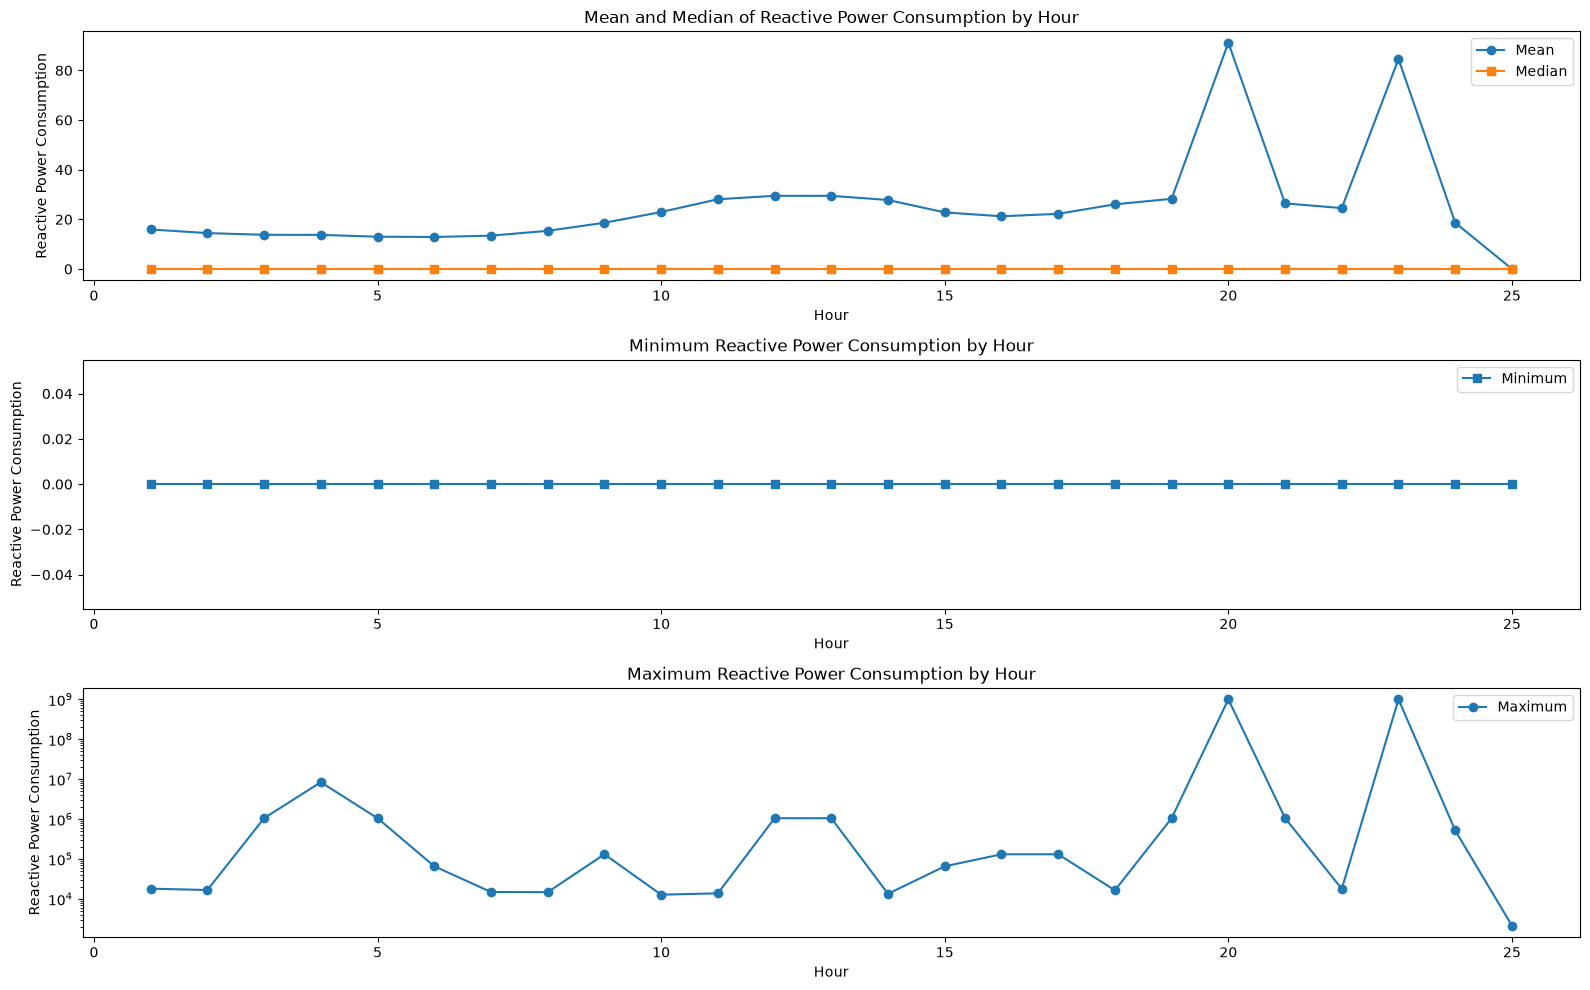

In [14]:
reactive_cols = [f"REACTIVE_H{i}" for i in range(1, 26)]
reactive_stats = []

for c in reactive_cols:
    row = (
        A.select([
            pl.col(c).min().alias("minimum"),
            pl.col(c).max().alias("maximum"),
            pl.col(c).mean().alias("mean"),
            pl.col(c).median().alias("median"),
        ])
        .collect()
        .row(0)
    )

    reactive_stats.append({
        "column": c,
        "minimum": row[0],
        "maximum": row[1],
        "mean": row[2],
        "median": row[3],
    })

reactive_stats_df = pl.DataFrame(reactive_stats)

time_position = list(range(1, 26))

plt.figure(figsize=(16, 10))

plt.subplot(3,1,1)
plt.plot(time_position, reactive_stats_df["mean"], marker='o', label='Mean')
plt.plot(time_position, reactive_stats_df["median"], marker='s', label='Median')
plt.title("Mean and Median of Reactive Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Reactive Power Consumption")
plt.legend()

plt.subplot(3,1,2)
plt.plot(time_position, reactive_stats_df["minimum"], marker='s', label='Minimum')
plt.title("Minimum Reactive Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Reactive Power Consumption")
plt.legend()

plt.subplot(3,1,3)
plt.plot(time_position, reactive_stats_df["maximum"], marker='o', label='Maximum')
plt.yscale('log')
plt.title("Maximum Reactive Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Reactive Power Consumption")
plt.legend()

plt.tight_layout()
plt.show()

## Power Factor Analysis

In [15]:
A = A.with_columns([
    pl.sum_horizontal([pl.col(c).cast(pl.Int64) for c in active_cols]).alias("DAILY_ACTIVE_CONSUMPTION"),
    pl.sum_horizontal([pl.col(c).cast(pl.Int64) for c in reactive_cols]).alias("DAILY_REACTIVE_CONSUMPTION")
])

A = A.with_columns([
    (pl.col("DAILY_ACTIVE_CONSUMPTION").pow(2) + pl.col("DAILY_REACTIVE_CONSUMPTION").pow(2))
    .sqrt()
    .alias("APPARENT_ENERGY"),
    
    pl.when(
        (pl.col("DAILY_ACTIVE_CONSUMPTION").pow(2) + pl.col("DAILY_REACTIVE_CONSUMPTION").pow(2)).sqrt() == 0
    )
    .then(None)
    .otherwise(pl.col("DAILY_ACTIVE_CONSUMPTION") / (pl.col("DAILY_ACTIVE_CONSUMPTION").pow(2) + pl.col("DAILY_REACTIVE_CONSUMPTION").pow(2)).sqrt())
    .alias("POWER_FACTOR")
])

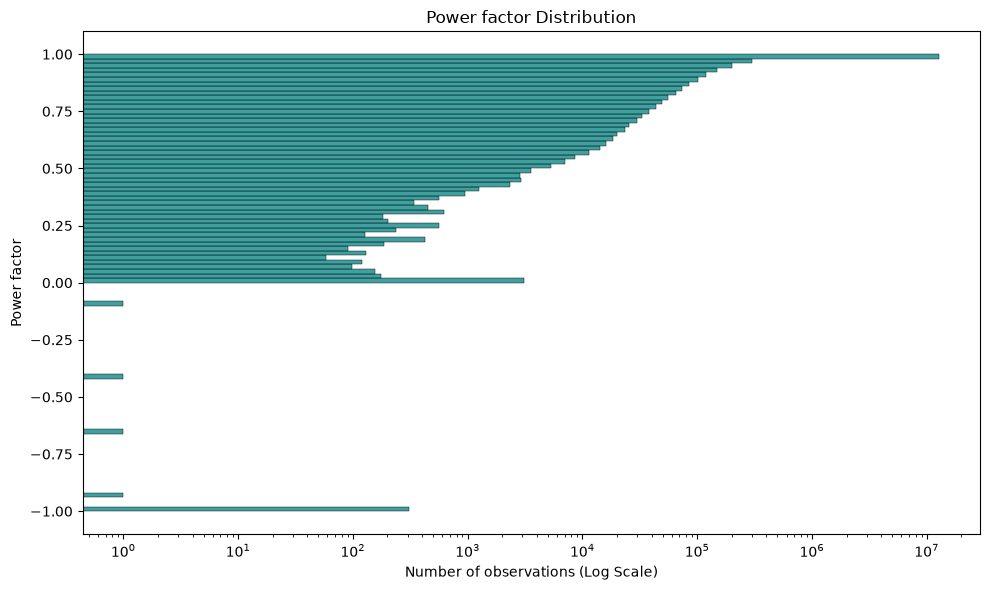

In [16]:
values = (
    A.select("POWER_FACTOR").collect().to_series().to_numpy()
)

plt.figure(figsize=(10, 6))

sns.histplot(y=values, bins=100, color="teal")

plt.xscale("log") 

plt.ylabel("Power factor")
plt.xlabel("Number of observations (Log Scale)")
plt.title("Power factor Distribution")

plt.tight_layout()
plt.show()

In [17]:
customer_pf = (
    A
    .group_by("CUSTOMER_ID")
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION").sum().alias("SUM_P"),
        pl.col("DAILY_REACTIVE_CONSUMPTION").sum().alias("SUM_Q"),
        pl.len().alias("N_DAYS_OBSERVED"),

        # How often does this customer have meaningful load?
        (pl.col("APPARENT_ENERGY") > 0).sum().alias("N_DAYS_WITH_LOAD"),

        # How often does this customer draw reactive power?
        (pl.col("DAILY_REACTIVE_CONSUMPTION") > 0).sum().alias("N_DAYS_WITH_Q"),

        # Fraction of days with PF below 0.95 (only counting loaded days)
        (
            (pl.col("DAILY_ACTIVE_CONSUMPTION") > 0)
            & (pl.col("POWER_FACTOR") < 0.95)
        ).sum().alias("N_DAYS_LOW_PF"),
    ])
    .with_columns([
        (pl.col("SUM_P").pow(2) + pl.col("SUM_Q").pow(2)).sqrt().alias("SUM_S"),
    ])
    .with_columns([
        pl.when(pl.col("SUM_S") == 0)
          .then(None)
          .otherwise(pl.col("SUM_P") / pl.col("SUM_S"))
          .alias("AGG_PF"),

        (pl.col("SUM_Q") / pl.col("SUM_P").abs()).alias("Q_OVER_P"),
        (pl.col("N_DAYS_LOW_PF") / pl.col("N_DAYS_WITH_LOAD")).alias("PCT_DAYS_LOW_PF"),
    ])
)

customer_pf.filter(pl.col("AGG_PF").is_nan() == False).sort("AGG_PF", descending=False).head().collect()

CUSTOMER_ID,SUM_P,SUM_Q,N_DAYS_OBSERVED,N_DAYS_WITH_LOAD,N_DAYS_WITH_Q,N_DAYS_LOW_PF,SUM_S,AGG_PF,Q_OVER_P,PCT_DAYS_LOW_PF
i64,i64,i64,u32,u32,u32,u32,f64,f64,f64,f64
14999,0,4,342,1,1,0,4.0,0.0,inf,0.0
79274,0,6,200,1,1,0,6.0,0.0,inf,0.0
77318,0,1,223,1,1,0,1.0,0.0,inf,0.0
13959,0,128,42,4,4,0,128.0,0.0,inf,0.0
84494,0,1,20,1,1,0,1.0,0.0,inf,0.0


Customers with valid inductive PF: 98,709
Customers with capacitive PF:      0
Customers that are net exporters: 0


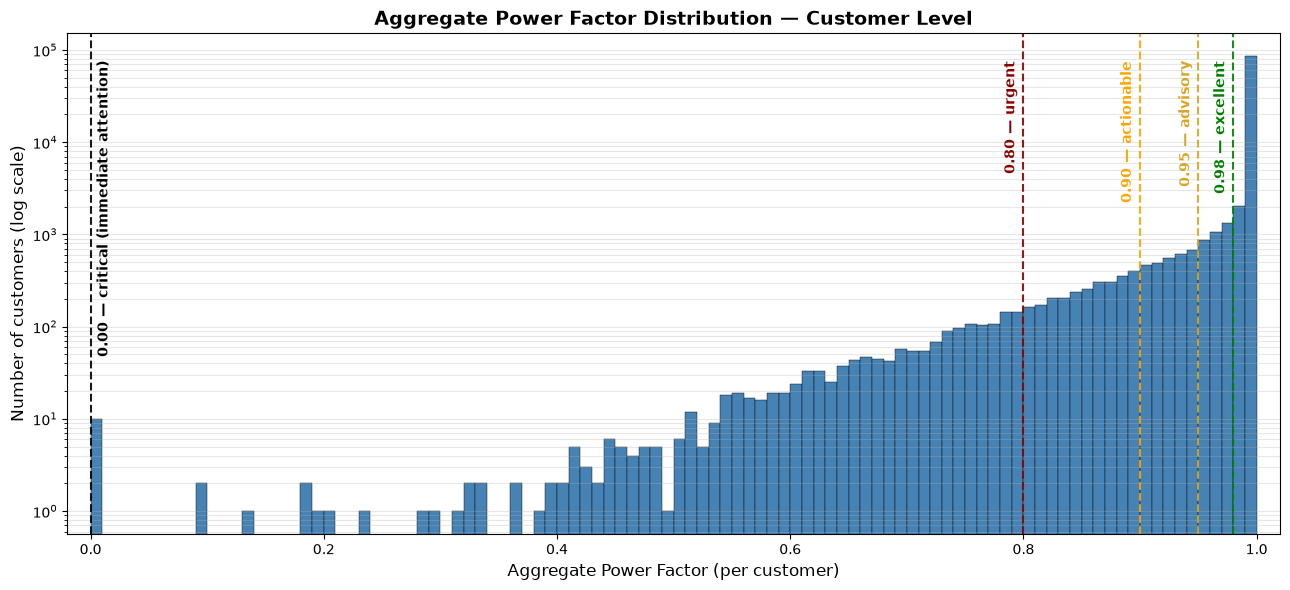

In [ ]:
# 1. Materialize customer_pf once — it is currently lazy
customer_pf_df = customer_pf.collect()

# 2. Extract AGG_PF as a NumPy array, dropping nulls
pf_all = (
    customer_pf_df
    .select("AGG_PF")
    .to_series()
    .drop_nulls()
    .to_numpy()
)

# 3. Split into physically distinct populations
pf_inductive = pf_all[(pf_all >= 0) & (pf_all <= 1)]   # normal / inductive load
pf_capacitive = pf_all[pf_all < 0]                     # leading PF

# 4. Count net exporters — this must also be evaluated eagerly
n_prosumers = (
    customer_pf_df
    .select((pl.col("SUM_P") < 0).sum().alias("n"))
    .item()
)

print(f"Customers with valid inductive PF: {len(pf_inductive):,}")
print(f"Customers with capacitive PF:      {len(pf_capacitive):,}")
print(f"Customers that are net exporters: {n_prosumers:,}")

# 5. Build the histogram
bins = np.linspace(0, 1, 101)
counts, edges = np.histogram(pf_inductive, bins=bins)

# 6. Plot setup (using a single, neutral color for bars to prevent threshold mismatch)
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(
    edges[:-1],
    counts,
    width=np.diff(edges),
    color="steelblue", 
    edgecolor="black",
    linewidth=0.3,
    align="edge",
)

ax.set_yscale("log")

# 7. Define warning thresholds and overlay lines
thresholds = [
    (0.00, "0.00 — critical (immediate attention)", "black"),
    (0.80, "0.80 — urgent",     "darkred"),
    (0.90, "0.90 — actionable", "orange"),
    (0.95, "0.95 — advisory",   "goldenrod"),
    (0.98, "0.98 — excellent",  "green"),
]

for thresh, label, color in thresholds:
    ax.axvline(thresh, color=color, linestyle="--", linewidth=1.5, alpha=0.9)
    
    # Adjust alignment for the 0.0 line to ensure the text remains visible
    ha = "left" if thresh == 0.0 else "right"
    offset = 0.005 if thresh == 0.0 else -0.005
    
    ax.text(
        thresh + offset,
        ax.get_ylim()[1] * 0.5,
        label,
        rotation=90,
        ha=ha,
        va="top",
        fontsize=10,
        fontweight="bold",
        color=color,
    )

# 8. Formatting
ax.set_xlabel("Aggregate Power Factor (per customer)", fontsize=12)
ax.set_ylabel("Number of customers (log scale)", fontsize=12)
ax.set_title("Aggregate Power Factor Distribution — Customer Level", fontsize=14, fontweight="bold")
ax.set_xlim(-0.02, 1.02) # Slightly expanded to fit the 0.0 label
ax.grid(axis="y", alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Negative consumption

Negative consumption value at any hour mean that during that time period the customer was selling electricity to the DSO rather than consuming it.

In [20]:
neg_active_cust = (
    A
    .filter(
        pl.any_horizontal([
            pl.col(c) < 0
            for c in active_cols
        ])
    )
    .collect()
    .to_pandas()
)
print(f"Rows with at least one negative active value: {len(neg_active_cust):,}")

Rows with at least one negative active value: 775


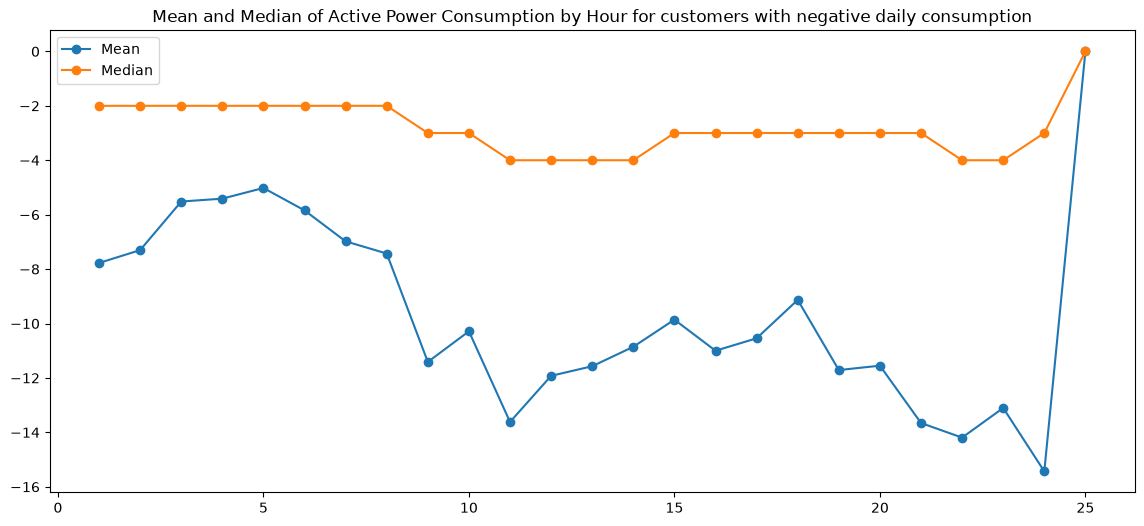

In [21]:
negative_daily_consumption = A.filter(pl.col("DAILY_ACTIVE_CONSUMPTION") < 0).collect().to_pandas()
negative_daily_consumption.shape

neg_active_stats = negative_daily_consumption[active_cols].describe()
plt.figure(figsize=(14, 6))
plt.plot(time_position, neg_active_stats.loc["mean"], marker='o', label='Mean')
plt.plot(time_position, neg_active_stats.loc["50%"], marker='o', label='Median')
plt.legend()
plt.title("Mean and Median of Active Power Consumption by Hour for customers with negative daily consumption")
plt.show()

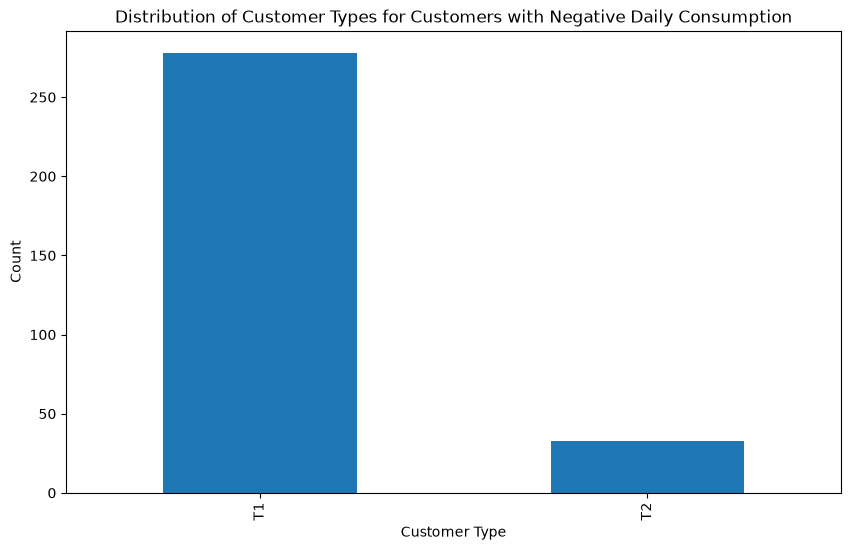

In [22]:
negative_daily_consumption["CUSTOMER_TYPE"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.title("Distribution of Customer Types for Customers with Negative Daily Consumption")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.show()

## Exploring the categorical variables

In [23]:
categorical_cols = [
    "CUSTOMER_TYPE",
    "ELECTRICITY_PRODUCT",
    "MARKET",
]

A = A.with_columns([
        pl.col(c).replace("", None)
        for c in categorical_cols
    ])

categorical_overview = (
    A.select([
        pl.col(c).n_unique().alias(c)
        for c in categorical_cols
    ])
    .collect()
)

categorical_overview

CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
u32,u32,u32
2,86,2


In [24]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(
        A.select(col)
        .unique()
        .sort(col)
        .head(30)
        .collect()
    )


--- CUSTOMER_TYPE ---
shape: (2, 1)
┌───────────────┐
│ CUSTOMER_TYPE │
│ ---           │
│ cat           │
╞═══════════════╡
│ T1            │
│ T2            │
└───────────────┘

--- ELECTRICITY_PRODUCT ---
shape: (30, 1)
┌─────────────────────┐
│ ELECTRICITY_PRODUCT │
│ ---                 │
│ cat                 │
╞═════════════════════╡
│ P1                  │
│ P106                │
│ P11                 │
│ P110                │
│ P111                │
│ …                   │
│ P28                 │
│ P29                 │
│ P3                  │
│ P30                 │
│ P31                 │
└─────────────────────┘

--- MARKET ---
shape: (2, 1)
┌────────┐
│ MARKET │
│ ---    │
│ cat    │
╞════════╡
│ M1     │
│ M2     │
└────────┘


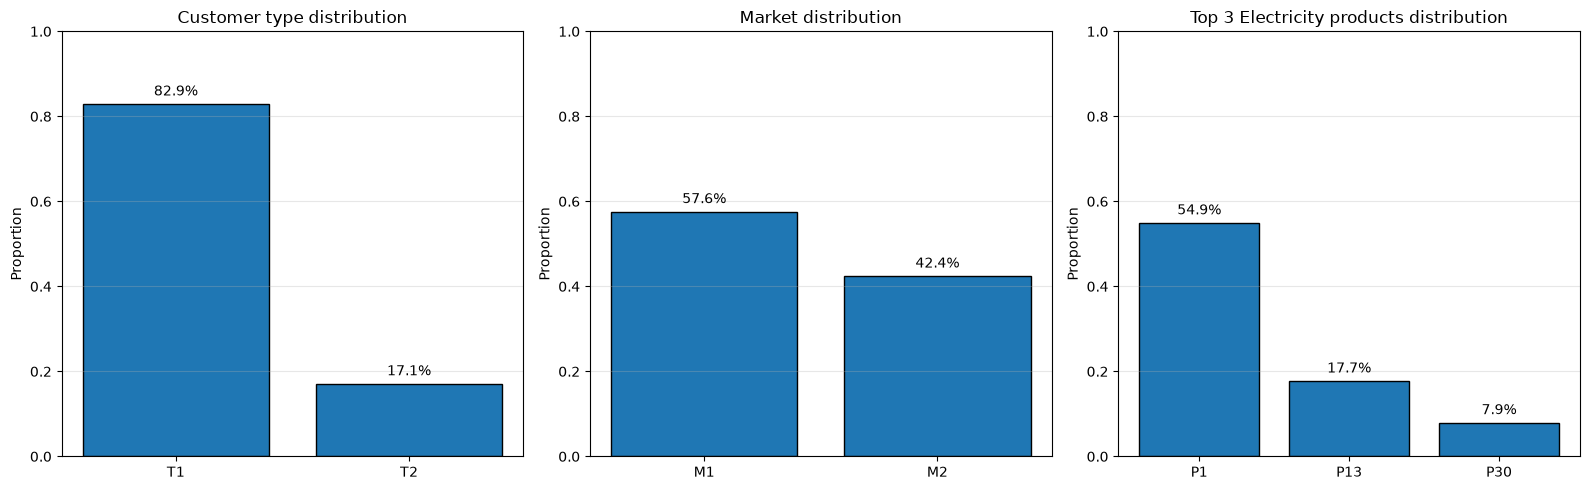

In [25]:
ct = (
    A.select(pl.col("CUSTOMER_TYPE").value_counts(normalize=True))
     .unnest("CUSTOMER_TYPE")
     .collect()
)

mk = (
    A.select(pl.col("MARKET").value_counts(normalize=True))
     .unnest("MARKET")
     .collect()
)

ep = (
    A.select(pl.col("ELECTRICITY_PRODUCT").value_counts(normalize=True))
     .unnest("ELECTRICITY_PRODUCT")
     .sort("proportion", descending=True)
     .collect()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(
    ct["CUSTOMER_TYPE"].to_list(),
    ct["proportion"].to_list(),
    edgecolor="black",
)
axes[0].set_title("Customer type distribution")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)

for x, y in zip(ct["CUSTOMER_TYPE"].to_list(), ct["proportion"].to_list()):
    axes[0].text(x, y + 0.02, f"{y:.1%}", ha="center")

axes[1].bar(
    mk["MARKET"].to_list(),
    mk["proportion"].to_list(),
    edgecolor="black",
)
axes[1].set_title("Market distribution")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)

for x, y in zip(mk["MARKET"].to_list(), mk["proportion"].to_list()):
    axes[1].text(x, y + 0.02, f"{y:.1%}", ha="center")

axes[2].bar(
    ep["ELECTRICITY_PRODUCT"].to_list()[:3],
    ep["proportion"].to_list()[:3],
    edgecolor="black",
)
axes[2].set_title("Top 3 Electricity products distribution")
axes[2].set_ylabel("Proportion")
axes[2].set_ylim(0, 1)
axes[2].grid(axis="y", alpha=0.3)

for x, y in zip(ep["ELECTRICITY_PRODUCT"].to_list()[:3], ep["proportion"].to_list()[:3]):
    axes[2].text(x, y + 0.02, f"{y:.1%}", ha="center")

plt.tight_layout()
plt.show()

## Supply registration period column

In [26]:
A.select([
    pl.col("SUPPLY_REGISTRATION_PERIOD").is_null().sum().alias("nulls"),
    (pl.col("SUPPLY_REGISTRATION_PERIOD") == "").sum().alias("empties"),
    pl.col("SUPPLY_REGISTRATION_PERIOD").n_unique().alias("distinct"),
]).collect()

nulls,empties,distinct
u32,u32,u32
338139,0,171


In [27]:
A = A.with_columns(
    pl.col("SUPPLY_REGISTRATION_PERIOD").replace("", None)
)

In [28]:
A.select("SUPPLY_REGISTRATION_PERIOD").unique().head().collect()

SUPPLY_REGISTRATION_PERIOD
str
"""Q11994"""
"""Q21987"""
"""Q11983"""
"""Q31997"""
"""Q21975"""


In [29]:
A.select(
    pl.col("SUPPLY_REGISTRATION_PERIOD").str.len_chars().alias("len")
).unique().collect()

len
u32
null
6


In [30]:
A = A.with_columns([
  pl.col("SUPPLY_REGISTRATION_PERIOD")
    .str.slice(1, 1)
    .cast(pl.Int8, strict=False)
    .alias("REG_QUARTER"),

  pl.col("SUPPLY_REGISTRATION_PERIOD")
    .str.slice(2, 5)
    .cast(pl.Int16, strict=False)
    .alias("REG_YEAR"),
])

A.select([
  pl.col("REG_QUARTER").is_null().sum().alias("q_nulls"),
  pl.col("REG_YEAR").is_null().sum().alias("y_nulls"),
]).collect()

q_nulls,y_nulls
u32,u32
338139,338139


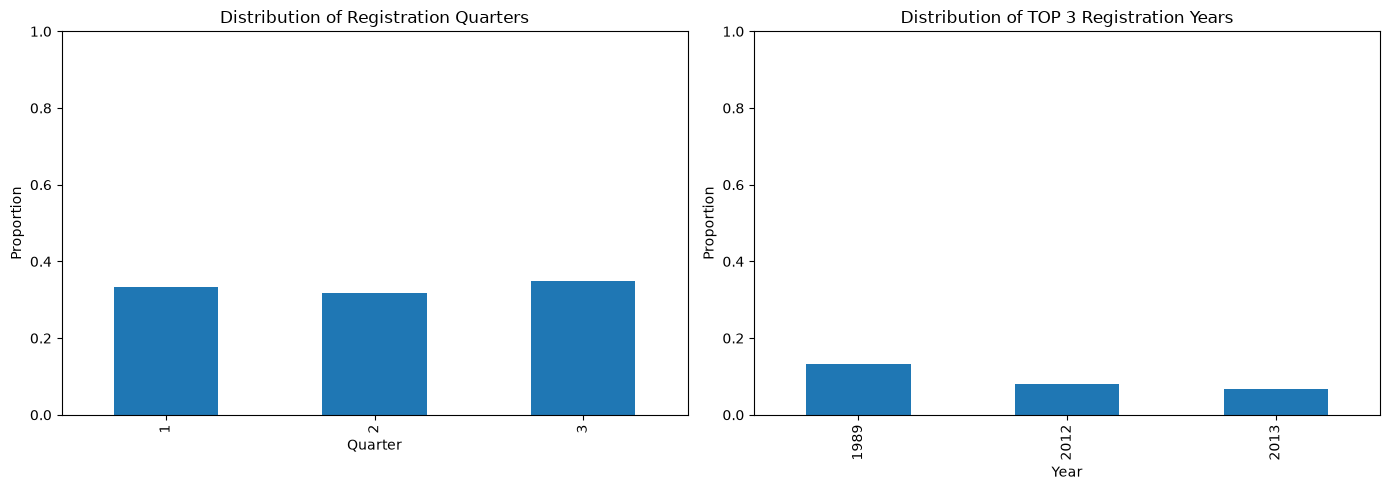

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

(
    A.filter(pl.col("REG_QUARTER").is_not_null())
    .select(pl.col("REG_QUARTER").value_counts(normalize=True))
    .unnest("REG_QUARTER")
    .sort("REG_QUARTER")
    .collect()
).to_pandas().plot(
    kind="bar",
    x="REG_QUARTER",
    y="proportion",
    legend=False,
    title="Distribution of Registration Quarters",
    xlabel="Quarter",
    ylabel="Proportion",
    ylim=(0, 1),
    ax=ax1, 
)

(
    A.filter(pl.col("REG_YEAR").is_not_null())
    .select(pl.col("REG_YEAR").value_counts(normalize=True))
    .unnest("REG_YEAR")
    .sort("proportion", descending=True)
    .head(3)
    .collect()
).to_pandas().plot(
    kind="bar",
    x="REG_YEAR",
    y="proportion",
    legend=False,
    title="Distribution of TOP 3 Registration Years",
    xlabel="Year",
    ylabel="Proportion",
    ylim=(0, 1),
    ax=ax2,
)

plt.tight_layout()
plt.show()


In [32]:
(
    A.filter(pl.col("REG_YEAR").is_not_null())
    .select(pl.col("REG_YEAR").unique().sort())
    .collect()
)

REG_YEAR
i16
1904
1952
1953
1957
1958
…
2011
2012
2013


## Customer Timeseries data Analysis

In [33]:
summary = (
    A
    .group_by("CUSTOMER_ID")
    .agg([
        pl.col("DATE").min().alias("FIRST_DATE"),
        pl.col("DATE").max().alias("LAST_DATE"),
        pl.col("DATE").n_unique().alias("DISTINCT_DAYS"),
    ])
    .with_columns(
        ((pl.col("LAST_DATE") - pl.col("FIRST_DATE")).dt.total_days() + 1)
            .alias("SPAN_DAYS")
    )
    .with_columns([
        (pl.col("SPAN_DAYS") - pl.col("DISTINCT_DAYS")).alias("MISSING_DAYS"),
        (pl.col("SPAN_DAYS") == pl.col("DISTINCT_DAYS")).alias("IS_CONTINUOUS"),
    ])
)
summary = summary.collect().to_pandas()
print(summary.shape[0])
summary.head()

99999


,CUSTOMER_ID,FIRST_DATE,LAST_DATE,DISTINCT_DAYS,SPAN_DAYS,MISSING_DAYS,IS_CONTINUOUS
0,63583,2014-11-19,2015-09-17,180,303,123,False
1,7348,2014-11-14,2015-09-17,304,308,4,False
2,20460,2014-11-03,2015-09-30,306,332,26,False
3,92150,2014-11-06,2015-10-01,124,330,206,False
4,76963,2014-11-04,2015-10-05,234,336,102,False


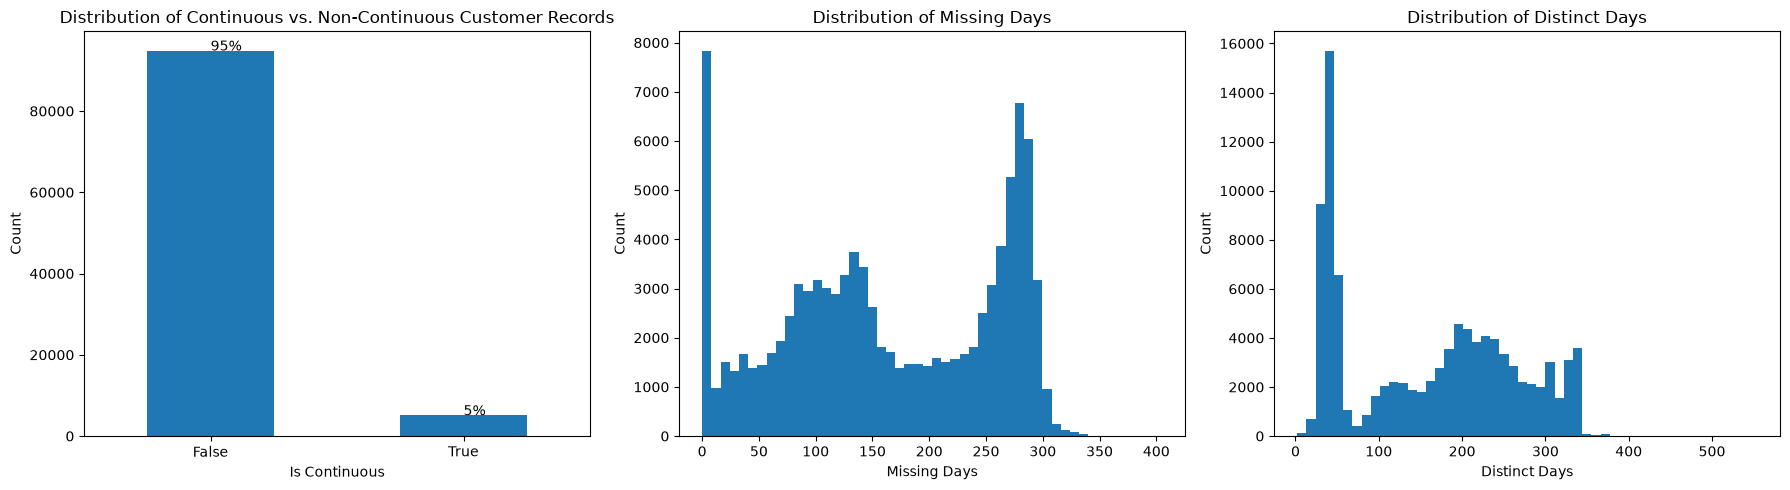

In [34]:
fig, (axes1, axes2, axes3) = plt.subplots(1, 3, figsize=(18, 5))
is_continuous = summary.IS_CONTINUOUS.value_counts()
is_continuous.plot(kind='bar', ax=axes1)
axes1.set_title("Distribution of Continuous vs. Non-Continuous Customer Records")
axes1.set_xlabel("Is Continuous")
axes1.set_ylabel("Count")
axes1.set_xticklabels(axes1.get_xticklabels(), rotation=0)
false_height = is_continuous[False]
true_height = is_continuous[True]
axes1.annotate(f"{is_continuous[False]/99999:.0%}", xy=(0, false_height+2))
axes1.annotate(f"{is_continuous[True]/99999:.0%}", xy=(1, true_height+2))

summary.DISTINCT_DAYS.plot(kind='hist', bins=50, ax=axes3)
axes3.set_title("Distribution of Distinct Days")
axes3.set_xlabel("Distinct Days")
axes3.set_ylabel("Count")

summary.MISSING_DAYS.plot(kind='hist', bins=50, ax=axes2)
axes2.set_title("Distribution of Missing Days")
axes2.set_xlabel("Missing Days")
axes2.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [48]:
runs = (
    A
    .sort(["CUSTOMER_ID", "DATE"])
    .with_columns(
        (pl.col("DATE").diff().dt.total_days() != 1)
            .fill_null(True)
            .cum_sum()
            .over("CUSTOMER_ID")
            .alias("RUN_ID")
    )
    .group_by(["CUSTOMER_ID", "RUN_ID"])
    .agg([
        pl.col("DATE").min().alias("RUN_START"),
        pl.col("DATE").max().alias("RUN_END"),
        pl.len().alias("RUN_LENGTH"),
    ])
)

per_customer_runs = (
    runs
    .group_by("CUSTOMER_ID")
    .agg([
        pl.len().alias("N_RUNS"),
        pl.col("RUN_LENGTH").max().alias("LONGEST_RUN"),
        pl.col("RUN_LENGTH").sum().alias("TOTAL_DAYS"),
    ])
)

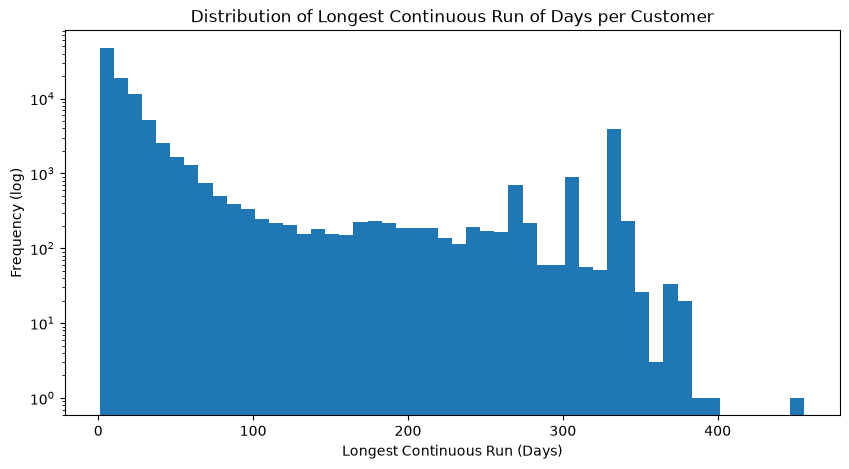

In [ ]:
per_customer_runs = per_customer_runs.collect().to_pandas()
per_customer_runs.LONGEST_RUN.plot(kind='hist', bins=50, figsize=(10, 5))
plt.title("Distribution of Longest Continuous Run of Days per Customer")
plt.xlabel("Longest Continuous Run (Days)")
plt.ylabel("Frequency (log)")
plt.yscale('log')
plt.show()

In [37]:
per_customer_runs.shape

(99999, 4)

In [38]:
runs = runs.collect().to_pandas()
runs.shape

(4556593, 5)

In [39]:
runs.head()

,CUSTOMER_ID,RUN_ID,RUN_START,RUN_END,RUN_LENGTH
0,82237,2,2015-01-13,2015-08-13,213
1,62017,21,2015-04-09,2015-04-09,1
2,33789,2,2014-11-17,2014-12-21,35
3,62925,3,2014-12-11,2014-12-11,1
4,7903,24,2015-07-17,2015-07-19,3


In [40]:
runs[runs["RUN_LENGTH"] >= 350].shape[0]

71

In [41]:
runs[runs["RUN_LENGTH"] >= 350]['CUSTOMER_ID'].nunique()

71

In [42]:
runs[runs["RUN_LENGTH"] >= 365].shape[0]

56

In [43]:
per_customer_runs[per_customer_runs["LONGEST_RUN"] >= 365].shape[0]

56

`Conclusion`: There is a total of 56 customers with consecutive data of more than or equal to a year (365 days)

## Exporting cleaned data

In [44]:
list(zip(A.collect_schema().names(), A.collect_schema().dtypes()))

[('CUSTOMER_ID', Int64),
 ('DATE', Date),
 ('ACTIVE_H1', Int32),
 ('REACTIVE_H1', Int32),
 ('ACTIVE_H2', Int32),
 ('REACTIVE_H2', Int32),
 ('ACTIVE_H3', Int32),
 ('REACTIVE_H3', Int32),
 ('ACTIVE_H4', Int32),
 ('REACTIVE_H4', Int32),
 ('ACTIVE_H5', Int32),
 ('REACTIVE_H5', Int32),
 ('ACTIVE_H6', Int32),
 ('REACTIVE_H6', Int32),
 ('ACTIVE_H7', Int32),
 ('REACTIVE_H7', Int32),
 ('ACTIVE_H8', Int32),
 ('REACTIVE_H8', Int32),
 ('ACTIVE_H9', Int32),
 ('REACTIVE_H9', Int32),
 ('ACTIVE_H10', Int32),
 ('REACTIVE_H10', Int32),
 ('ACTIVE_H11', Int32),
 ('REACTIVE_H11', Int32),
 ('ACTIVE_H12', Int32),
 ('REACTIVE_H12', Int32),
 ('ACTIVE_H13', Int32),
 ('REACTIVE_H13', Int32),
 ('ACTIVE_H14', Int32),
 ('REACTIVE_H14', Int32),
 ('ACTIVE_H15', Int32),
 ('REACTIVE_H15', Int32),
 ('ACTIVE_H16', Int32),
 ('REACTIVE_H16', Int32),
 ('ACTIVE_H17', Int32),
 ('REACTIVE_H17', Int32),
 ('ACTIVE_H18', Int32),
 ('REACTIVE_H18', Int32),
 ('ACTIVE_H19', Int32),
 ('REACTIVE_H19', Int32),
 ('ACTIVE_H20', Int32),
 (

In [45]:
A.select(pl.len()).collect().item()

15984952

In [46]:
(
    A
    .sink_parquet(
        PROJECT_ROOT / "data" / "A_analysis.parquet",
        compression="zstd",
        row_group_size=500_000,
    )
)